## Анализ зависимости суммы операции и типа операции

In [33]:
import pyspark
from pyspark.ml import Transformer, Pipeline
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.sql.functions import first, sum, col, max, min,avg
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# создание spark-сессии
spark =SparkSession.builder \
    .appName("analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "1g") \
    .getOrCreate()

## ANALYTICS POSTPROCESS

In [35]:
train_path = "../datasets/joined/train_data.parquet"
df_train = spark.read.parquet(train_path)

c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning:

invalid value encountered in subtract



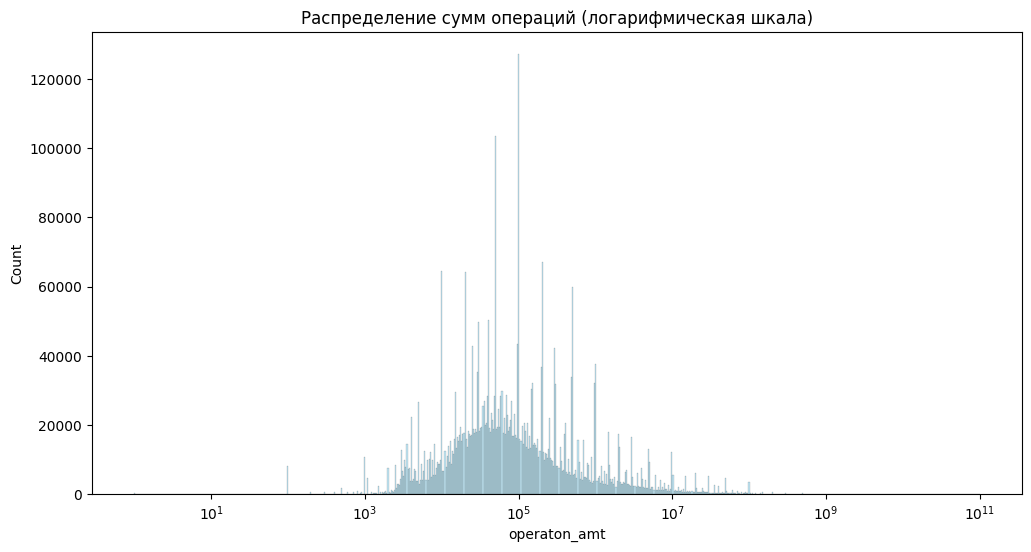

In [36]:
# 1. Берем 10% данных без повторений
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select("operaton_amt").sample(False, 0.1).toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="operaton_amt", kde=True, log_scale=True, color="skyblue")
plt.title("Распределение сумм операций (логарифмическая шкала)")
plt.show()

## ИЩЕМ ФРОД

c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning:

invalid value encountered in subtract



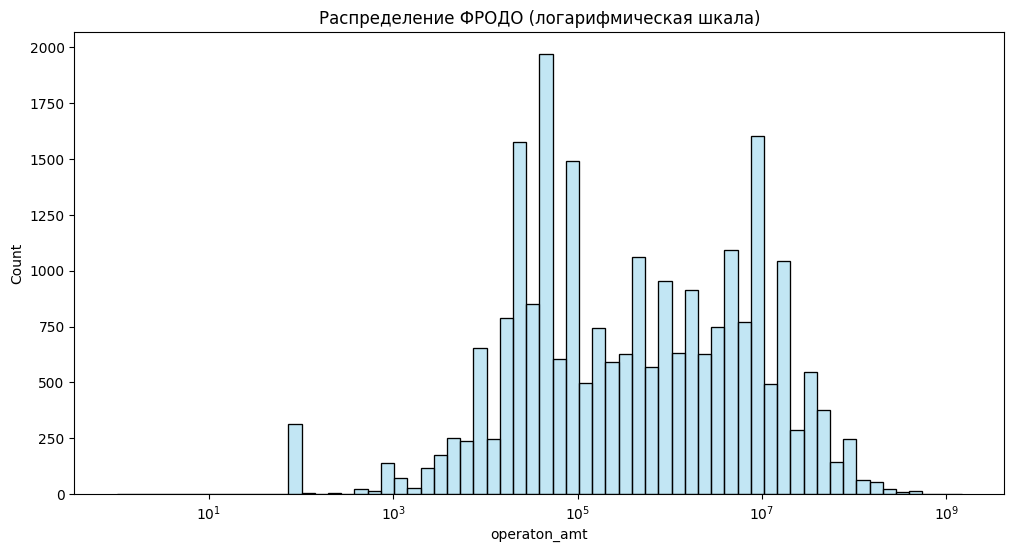

In [38]:
# 1. Берем 10% данных без повторений
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select("operaton_amt").filter('target == 1').toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="operaton_amt", kde=True, log_scale=True, color="skyblue")
plt.title("Распределение ФРОДО (логарифмическая шкала)")
plt.show()

## РАСПРЕДЕЛЕНИЕ ФРОДОВ ПЕРЕВОДОВ В ЗАВИСИМОСТИ ОТ ТИПА ОПЕРАЦИИ

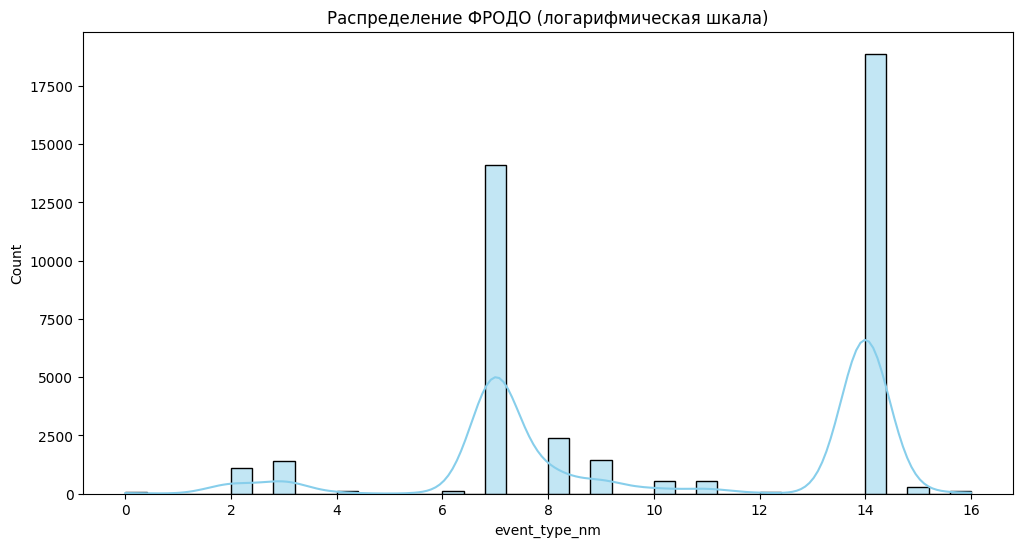

In [ ]:
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select('event_type_nm').filter('target == 1').toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="event_type_nm", kde=True, color="skyblue")
plt.title("Распределение ФРОДО (логарифмическая шкала)")
plt.show()

## ВСЕГДА ЛИ ФРОД В ВЗЛОМАННЫХ УСТРОЙСТВАХ?

In [ ]:

pdf1 = df_train.select('compromised').filter('target == 1').toPandas()
pdf2 = df_train.select('compromised').filter('target == 0').sample(False, 0.1).toPandas()
plt.figure(figsize=(12, 6))

sns.histplot(data=pdf1, x="compromised", kde=True, color="skyblue")
sns.histplot(data=pdf2, x="compromised", kde=True, color="skyblue")

plt.title("Распределение ФРОДО (логарифмическая шкала)")
plt.show()

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\py4j\java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\py4j\clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
KeyboardInterrupt


KeyboardInterrupt: 